[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_A_neoclassical_growth_local.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The Neoclassical Growth Model: Detrending, Log-Linearization, and Local Approximation

**How do we compute the policy rules of a dynamic economy when non-linearities prevent closed-form algebraic solutions?** In the neoclassical growth model (Ramsey 1928, Cass 1965, Koopmans 1965), households choose consumption, savings, and hours worked across an infinite horizon, trading off current versus future marginal utility and labor versus leisure. Because the Euler equation and resource constraints form a system of non-linear difference equations with expectations, macroeconomic practice relies on two distinct computational paths: **global non-linear methods** (such as Value Function Iteration) and **local perturbation approximations** around the deterministic steady state (Blanchard & Kahn 1980, Klein 2000).

This notebook implements the complete pedagogical journey from **Slides 02**:
1. **Economic Foundations & Balanced Growth Path**: Detrending exogenous technological progress $(1+g)$ to convert long-run growth into a stationary system.
2. **Declarative Dynare in Pure Python**: Authoring and executing the 20-line model from Slide 808 via `puremacro.dsge.load_mod` with zero MATLAB/Octave dependencies.
3. **Klein (2000) QZ Decomposition**: Inspecting state-space policy matrices $G, F, N, L$, stable saddle-path roots, and verifying the Blanchard-Kahn conditions.
4. **Permanent vs. Transitory Productivity Shocks**: Simulating the $+2\%$ permanent transition ("MIT shock", Boppart, Krusell & Mitman 2018) with stacked Newton-Raphson relaxation (`solve_perfect_foresight`) and contrasting it with AR(1) transitory dynamics.
5. **The Confrontation Laboratory**: Quantifying policy discrepancies and Euler equation residuals between 1st-order local Taylor expansions and global non-linear solutions.
6. **Interactive Experiment**: Simulating anticipated technology announcements ("news shocks") under perfect foresight.

In [2]:
# ==============================================================================
# Analytical Steady State & Exact Residual Verification
# ==============================================================================
def solve_neoclassical_ss(alpha=0.33, beta=0.97, delta=0.06, gamma=1.0, n_bar=1.0, a_val=1.0):
    """Compute the exact analytical steady state for the neoclassical growth model.
    
    Calibration (Annual, Slide 808):
      alpha = 0.33  (capital share)
      beta  = 0.97  (annual discount factor)
      delta = 0.06  (annual capital depreciation)
      gamma = 1.0   (leisure preference weight)
      n_bar = 1.0   (time endowment)
      a_val = 1.0   (baseline TFP)
    """
    # From the Euler equation in steady state: 1/beta = alpha * (y/k) + 1 - delta
    yk = (1.0 / beta - 1.0 + delta) / alpha
    ky = 1.0 / yk
    cy = 1.0 - delta * ky

    # From the intratemporal labor-leisure condition:
    # gamma * c / (n - l) = (1 - alpha) * y / l  =>  gamma * cy / (n - l) = (1 - alpha) / l
    l_ss = (1.0 - alpha) * n_bar / (gamma * cy + 1.0 - alpha)

    # From the Cobb-Douglas production function: y = a * k^alpha * l^(1-alpha)
    # y = a * (ky * y)^alpha * l^(1-alpha)  =>  y^(1-alpha) = a * ky^alpha * l^(1-alpha)
    y_ss = (a_val ** (1.0 / (1.0 - alpha))) * (ky ** (alpha / (1.0 - alpha))) * l_ss
    k_ss = ky * y_ss
    c_ss = cy * y_ss
    r_ss = alpha * y_ss / k_ss
    w_ss = (1.0 - alpha) * y_ss / l_ss

    return {
        "y": float(y_ss),
        "c": float(c_ss),
        "k": float(k_ss),
        "l": float(l_ss),
        "r": float(r_ss),
        "w": float(w_ss),
        "ky": float(ky),
        "cy": float(cy),
    }

ss_base = solve_neoclassical_ss(a_val=1.0)
ss_new  = solve_neoclassical_ss(a_val=1.02)

# Verify zero residuals against the structural equations
def check_steady_state_residuals(ss, a_val, alpha=0.33, beta=0.97, delta=0.06, gamma=1.0, n_bar=1.0):
    res_intra = gamma * ss["c"] / (n_bar - ss["l"]) - (1.0 - alpha) * ss["y"] / ss["l"]
    res_euler = 1.0 / beta - (alpha * ss["y"] / ss["k"] + 1.0 - delta)
    res_feas  = ss["c"] + delta * ss["k"] - ss["y"]
    res_prod  = ss["y"] - a_val * (ss["k"] ** alpha) * (ss["l"] ** (1.0 - alpha))
    return np.array([res_intra, res_euler, res_feas, res_prod])

res_check = check_steady_state_residuals(ss_base, 1.0)
assert np.all(np.abs(res_check) < 1e-13), f"Non-zero steady state residual: {res_check}"

ss_table = pd.DataFrame([
    {"Variable": "Output (y)", "Level (A=1.00)": ss_base["y"], "Level (A=1.02)": ss_new["y"], "% Change": (ss_new["y"]/ss_base["y"] - 1) * 100},
    {"Variable": "Consumption (c)", "Level (A=1.00)": ss_base["c"], "Level (A=1.02)": ss_new["c"], "% Change": (ss_new["c"]/ss_base["c"] - 1) * 100},
    {"Variable": "Capital (k)", "Level (A=1.00)": ss_base["k"], "Level (A=1.02)": ss_new["k"], "% Change": (ss_new["k"]/ss_base["k"] - 1) * 100},
    {"Variable": "Hours (l)", "Level (A=1.00)": ss_base["l"], "Level (A=1.02)": ss_new["l"], "% Change": (ss_new["l"]/ss_base["l"] - 1) * 100},
    {"Variable": "Real Wage (w)", "Level (A=1.00)": ss_base["w"], "Level (A=1.02)": ss_new["w"], "% Change": (ss_new["w"]/ss_base["w"] - 1) * 100},
    {"Variable": "Rental Rate (r)", "Level (A=1.00)": ss_base["r"], "Level (A=1.02)": ss_new["r"], "% Change": (ss_new["r"]/ss_base["r"] - 1) * 100},
])

print("Analytical Steady State (Slides02 Annual Calibration):")
print(ss_table.to_string(index=False))

Analytical Steady State (Slides02 Annual Calibration):
       Variable  Level (A=1.00)  Level (A=1.02)  % Change
     Output (y)        0.870494        0.896606  2.999728
Consumption (c)        0.680939        0.701366  2.999728
    Capital (k)        3.159242        3.254010  2.999728
      Hours (l)        0.461355        0.461355  0.000000
  Real Wage (w)        1.264170        1.302092  2.999728
Rental Rate (r)        0.090928        0.090928  0.000000


## Declarative Dynare in Pure Python: The 20-Line Model from Slide 808

Slide 808 of `Slides02mav.tex` highlights that a complete neoclassical growth model can be specified in exactly twenty lines of `.mod` syntax. In standard macro toolchains, executing this specification required commercial MATLAB licenses or Octave binaries. `puremacro.dsge.load_mod` eliminates that dependency: it parses standard Dynare `.mod` files directly in Python, evaluates exact complex-step Jacobians at the deterministic steady state, classifies variables into predetermined states and forward-looking controls, and computes the stable rational expectations policy function via Klein's (2000) generalized Schur (QZ) decomposition.

Let us inspect the structural equations declared in `modelos/neoclasico_prevision_perfecta.mod`:
1. **Intratemporal Efficiency**: $\frac{\gamma c_t}{n - l_t} = (1-\alpha)\frac{y_t}{l_t}$
2. **Intertemporal Euler Equation**: $\frac{c_{t+1}}{\beta c_t} = \alpha \frac{y_{t+1}}{k_t} + 1 - \delta$
3. **Resource Constraint**: $c_t + k_t - (1-\delta)k_{t-1} = y_t$
4. **Production Function**: $y_t = e^{a_t} k_{t-1}^\alpha l_t^{1-\alpha}$
5. **Technology Process**: $a_t = \rho_a a_{t-1} + \varepsilon_{a,t}$

In [3]:
from puremacro.dsge import load_mod

from _datos import ruta_modelo

# Resolve model path across local repository, sandbox, and Colab environments
mod_path = ruta_modelo("neoclasico_prevision_perfecta.mod")

# Harmless: puremacro's steady-state solver probes the call signature with every variable at 1, which divides by zero in this model's equations; that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide", category=RuntimeWarning)
    m_local = load_mod(mod_path)

print(f"Model successfully loaded: {mod_path}")
print(f"Predetermined States (x_t) : {m_local.states}")
print(f"Forward Controls     (y_t) : {m_local.controls}")
print(f"Structural Shocks    (u_t) : {m_local.shocks}")

# Display Dynare-format decision rules
dr_table = m_local.decision_rules().to_frame()
print("\nPOLICY AND TRANSITION FUNCTIONS (Dynare Format):")
print(dr_table.round(6))

# Blanchard-Kahn Eigenvalue Diagnostics
print("\nGeneralized Eigenvalues of the System (Klein QZ):")
for idx, eig in enumerate(m_local.eigenvalues):
    mod_eig = abs(eig)
    status = "Stable (inside unit circle)" if mod_eig < 1.0 else "Explosive (jump variable anchor)"
    print(f"  lambda_{idx+1} = {eig:.6f}  (|lambda| = {mod_eig:.6f}) -> {status}")

Model successfully loaded: modelos/neoclasico_prevision_perfecta.mod
Predetermined States (x_t) : ('k', 'a')
Forward Controls     (y_t) : ('y', 'c', 'l')
Structural Shocks    (u_t) : ('e_a',)

POLICY AND TRANSITION FUNCTIONS (Dynare Format):
                 y         c         k         l     a
Constant  0.870494  0.680939  3.159242  0.461355  0.00
k(-1)     0.059540  0.114608  0.884932 -0.024829  0.00
a(-1)     1.029201  0.366744  0.662456  0.159972  0.95
e_a       1.083369  0.386047  0.697323  0.168391  1.00

Generalized Eigenvalues of the System (Klein QZ):
  lambda_1 = 0.884932  (|lambda| = 0.884932) -> Stable (inside unit circle)
  lambda_2 = 0.950000  (|lambda| = 0.950000) -> Stable (inside unit circle)
  lambda_3 = 1.164980  (|lambda| = 1.164980) -> Explosive (jump variable anchor)
  lambda_4 = 14551014159809818.000000  (|lambda| = 14551014159809818.000000) -> Explosive (jump variable anchor)
  lambda_5 = 173843295662932928.000000  (|lambda| = 173843295662932928.000000) -> Expl

## Transitory Productivity Shocks: Dynamics & Impulse Responses

When a transitory AR(1) productivity shock $\varepsilon_{a,t}$ hits the economy, the dynamic response illustrates the fundamental transmission mechanism of the neoclassical model:
- **Impact ($t=0$)**: The temporary increase in $a_t$ raises the marginal product of labor, inducing an immediate upward jump in hours worked ($l_t$) via the substitution effect. Output surges.
- **Consumption Smoothing**: Households choose not to consume the entire temporary windfall today. Because $\beta(1-\delta + r_{t+1})$ rises, saving increases dramatically and capital $k_t$ accumulates.
- **Propagation ($t > 0$)**: As technology decays back toward steady state at rate $\rho_a = 0.95$, the elevated capital stock remains, sustaining higher output and wages even after the technology shock has subsided. Eventually, capital depreciates back to $k_{ss}$.

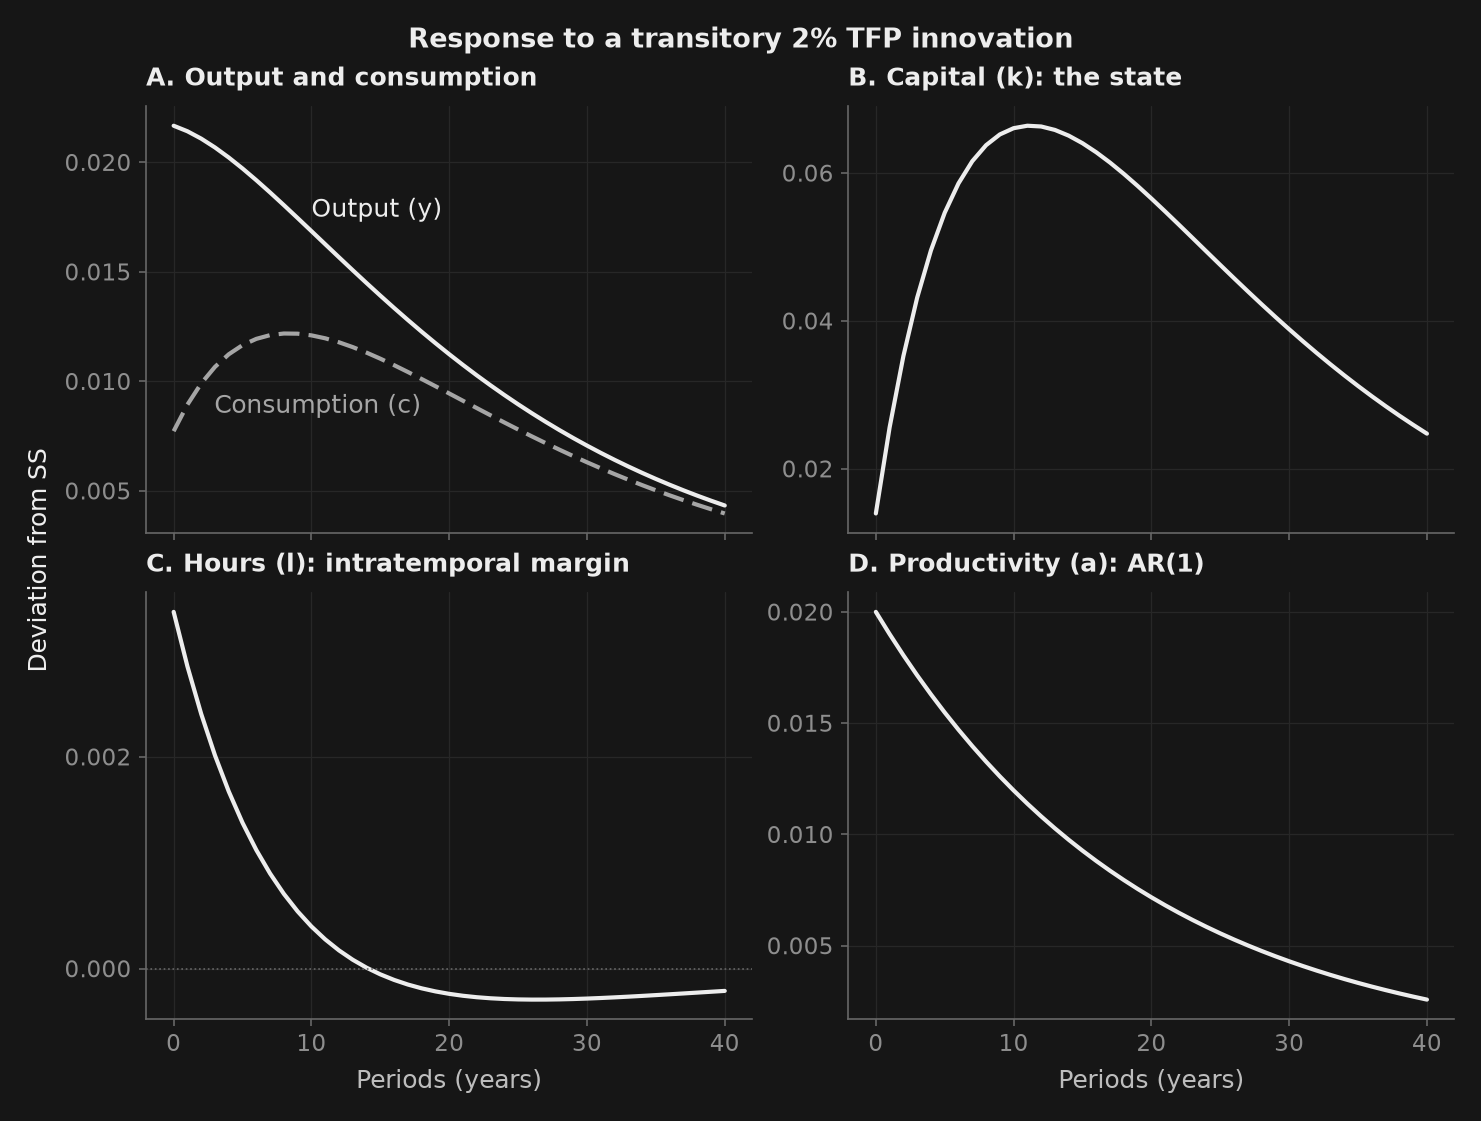

In [4]:
# Generate 40-period impulse response functions
irf_df = m_local.irf("e_a", horizon=40, size=0.02)  # 2% positive TFP innovation

# Under the "lamina" profile the figure inherits the slide slot's size;
# in the notebook it takes the course grid.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, axes = _nbstyle.figura(2, 2, sharex=True, figsize=_ranura)

# 1. Output and Consumption
ax = axes[0, 0]
ax.plot(irf_df.index, irf_df["y"], **_nbstyle.S1)
ax.plot(irf_df.index, irf_df["c"], **_nbstyle.S2)
# The names sit inside the axes and in data units, so they follow their line
# at 6.4 inches and at slot width alike
ax.annotate("Output (y)", xy=(10, np.interp(10, irf_df.index, irf_df["y"])), xytext=(0, 4),
            textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TINTA)
ax.annotate("Consumption (c)", xy=(2.5, np.interp(2.5, irf_df.index, irf_df["c"])), xytext=(3, -9),
            textcoords="offset points", ha="left", va="top", color=_nbstyle.S2["color"])
ax.set_title("A. Output and consumption")

# 2. Capital Stock
ax = axes[0, 1]
ax.plot(irf_df.index, irf_df["k"], **_nbstyle.S1)
ax.set_title("B. Capital (k): the state")

# 3. Hours Worked
ax = axes[1, 0]
ax.plot(irf_df.index, irf_df["l"], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax.set_title("C. Hours (l): intratemporal margin")
ax.set_xlabel("Periods (years)")

# 4. Productivity Process
ax = axes[1, 1]
ax.plot(irf_df.index, irf_df["a"], **_nbstyle.S1)
ax.set_title("D. Productivity (a): AR(1)")
ax.set_xlabel("Periods (years)")

# One vertical axis label for the four panels, and few ticks: at slot width
# four repeated labels do not fit.
for ax in axes.flat:
    ax.locator_params(axis="y", nbins=4)
fig.supylabel("Deviation from SS", fontsize=plt.rcParams["axes.labelsize"])

fig.suptitle("Response to a transitory 2% TFP innovation")
plt.show()


## Permanent Productivity Shifts: The MIT Shock & Perfect Foresight

Slide 849 of `Slides02mav.tex` displays the non-linear transition path when productivity experiences a **permanent $+2\%$ shift** ($\Delta a = +0.02$ for all $t \ge 1$). In macroeconomic theory, this is an **MIT shock** (Boppart, Krusell & Mitman 2018):
- The shift is completely unanticipated at $t=0$.
- Once announced at $t=1$, agents have perfect foresight regarding the future trajectory of technology.

**Why local linear approximation fails for permanent shifts**: A first-order Taylor expansion around the initial steady state linearizes the policy function at $k_{ss}(A=1.0)$. However, a permanent $+2\%$ shock permanently shifts the economy to a new target steady state $k_{ss}(A=1.02) = 3.254$, introducing cumulative approximation drift.

To capture the exact non-linear trajectory, `puremacro.dsge.solve_perfect_foresight` implements the **stacked Newton-Raphson relaxation algorithm** (Boucekkine 1995, Juillard 1996), solving the full system of non-linear difference equations across the entire horizon $t=1,\dots,T$ simultaneously.

Stacked Newton-Raphson Convergence: True
Iterations: 4 | Residual Norm: 8.88e-16
Initial Capital (k_0) : 3.1701
Terminal Capital (k_T): 3.2540 (Target SS: 3.2540)


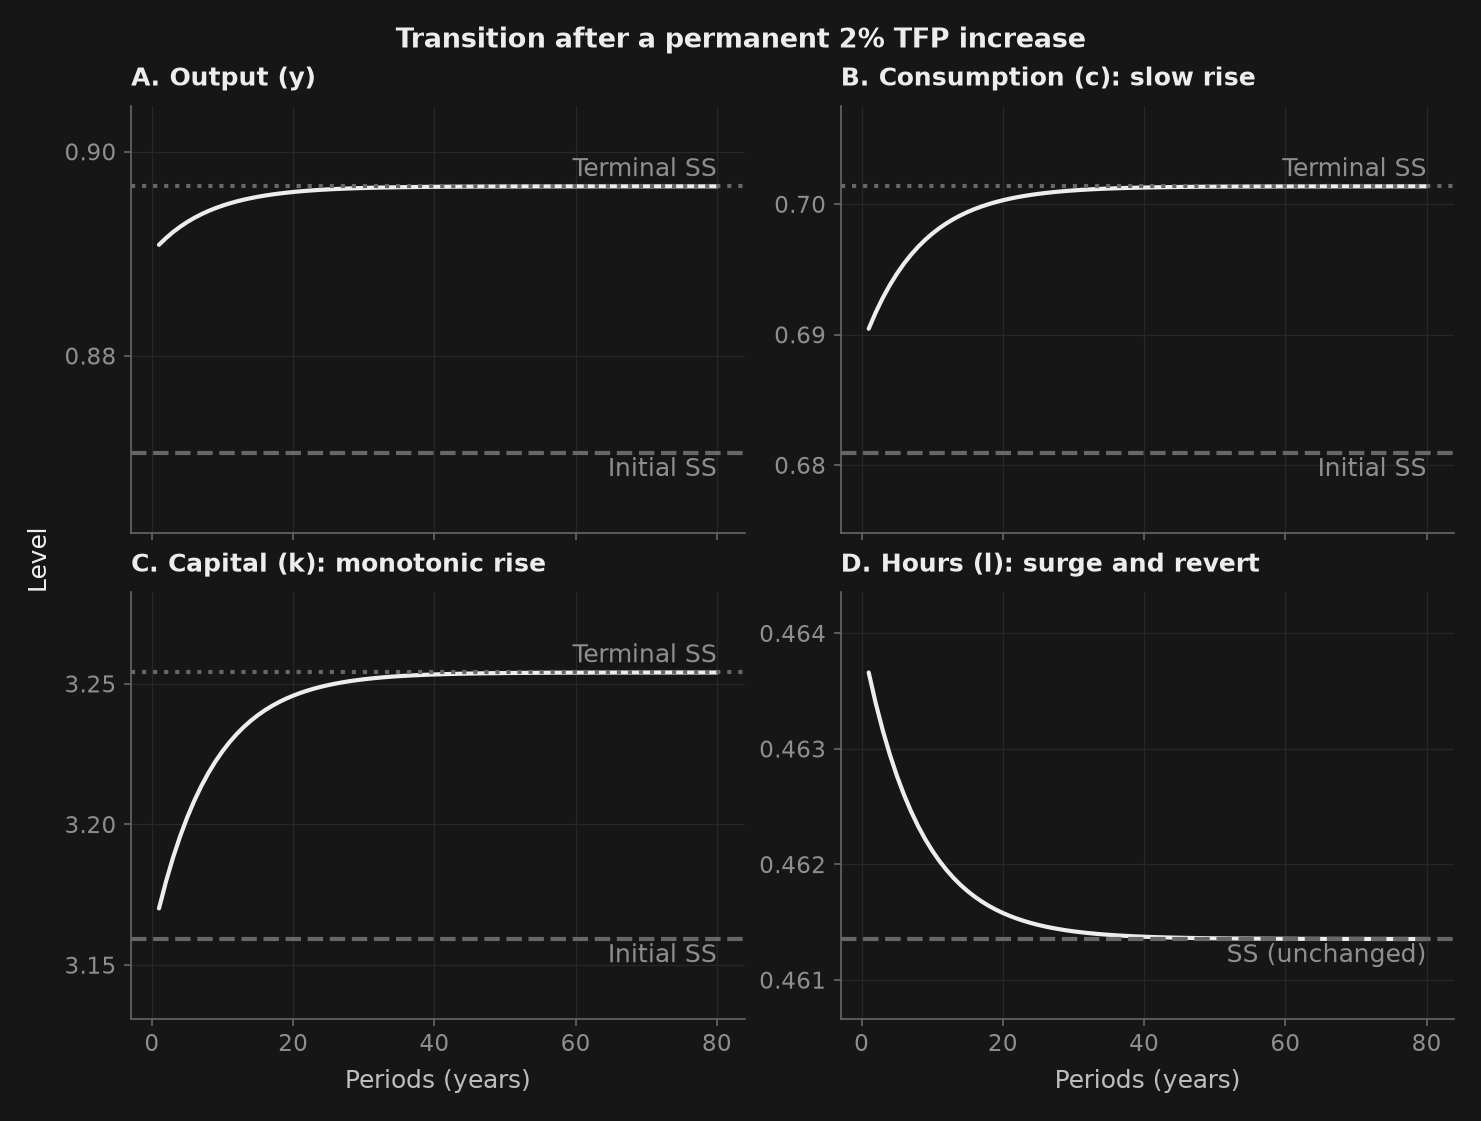

In [5]:
from puremacro.dsge import solve_perfect_foresight

# Define the non-linear equilibrium equations for the stacked solver
def neoclassical_stacked_equations(y_plus, y_curr, y_lag, eps):
    y_next, c_next, k_next, l_next = y_plus
    y_now,  c_now,  k_now,  l_now  = y_curr
    y_prev, c_prev, k_prev, l_prev = y_lag
    a_val = float(eps) if np.ndim(eps) == 0 else float(eps[0])

    # 1. Intratemporal labor-leisure condition
    eq1 = 1.0 * c_now / (1.0 - l_now) - (1.0 - 0.33) * y_now / l_now
    # 2. Intertemporal Euler equation
    eq2 = c_next / (0.97 * c_now) - (0.33 * y_next / k_now + 1.0 - 0.06)
    # 3. Capital resource constraint (k_now is k_t, k_prev is k_{t-1})
    eq3 = c_now + k_now - (1.0 - 0.06) * k_prev - y_now
    # 4. Cobb-Douglas production function
    eq4 = y_now - a_val * (k_prev ** 0.33) * (l_now ** (1.0 - 0.33))

    return [eq1, eq2, eq3, eq4]

T_horizon = 80
a_permanent = np.full(T_horizon, 1.02)  # Permanent +2% shift in TFP

y_init_vector = np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]])
y_ss_target   = np.array([ss_new["y"],  ss_new["c"],  ss_new["k"],  ss_new["l"]])

# Execute stacked Newton-Raphson solver
pf_result = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=y_init_vector,
    y_ss=y_ss_target,
    exogenous_path=a_permanent,
    n_periods=T_horizon,
    variable_names=["y", "c", "k", "l"],
    tol=1e-10,
)

print(f"Stacked Newton-Raphson Convergence: {pf_result.converged}")
print(f"Iterations: {pf_result.iterations} | Residual Norm: {pf_result.residual_norm:.2e}")
print(f"Initial Capital (k_0) : {pf_result.path.loc[1, 'k']:.4f}")
print(f"Terminal Capital (k_T): {pf_result.path.loc[T_horizon, 'k']:.4f} (Target SS: {ss_new['k']:.4f})")

# Replicate Slide 849 Figure
# Under the "lamina" profile the figure inherits the slide slot's size;
# in the notebook it takes the course grid.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, axes = _nbstyle.figura(2, 2, sharex=True, figsize=_ranura)
T_fin = pf_result.path.index[-1]


def marcar_ee(ax, inicial, terminal=None, nombre_inicial="Initial SS"):
    """Draw and name the initial and terminal steady-state reference lines."""
    ax.axhline(inicial, color=_nbstyle.SPINE, ls="--")
    ax.annotate(nombre_inicial, xy=(T_fin, inicial), xytext=(0, -2), textcoords="offset points",
                ha="right", va="top", color=_nbstyle.NOTA)
    if terminal is not None:
        ax.axhline(terminal, color=_nbstyle.SPINE, ls=":")
        ax.annotate("Terminal SS", xy=(T_fin, terminal), xytext=(0, 2), textcoords="offset points",
                    ha="right", va="bottom", color=_nbstyle.NOTA)
    # The labels live in the margin, outside the data range: at slot height
    # they need more air than usual to fit whole.
    ax.margins(y=0.30)


# 1. Output Transition
ax = axes[0, 0]
ax.plot(pf_result.path.index, pf_result.path["y"], **_nbstyle.S1)
marcar_ee(ax, ss_base["y"], ss_new["y"])
ax.set_title("A. Output (y)")

# 2. Consumption Transition
ax = axes[0, 1]
ax.plot(pf_result.path.index, pf_result.path["c"], **_nbstyle.S1)
marcar_ee(ax, ss_base["c"], ss_new["c"])
ax.set_title("B. Consumption (c): slow rise")

# 3. Capital Stock Transition
ax = axes[1, 0]
ax.plot(pf_result.path.index, pf_result.path["k"], **_nbstyle.S1)
marcar_ee(ax, ss_base["k"], ss_new["k"])
ax.set_title("C. Capital (k): monotonic rise")
ax.set_xlabel("Periods (years)")

# 4. Hours Worked Transition
ax = axes[1, 1]
ax.plot(pf_result.path.index, pf_result.path["l"], **_nbstyle.S1)
marcar_ee(ax, ss_base["l"], nombre_inicial="SS (unchanged)")
ax.set_title("D. Hours (l): surge and revert")
ax.set_xlabel("Periods (years)")

# One vertical label for the four panels, and few ticks: at slot width four
# repeated labels do not fit.
for ax in axes.flat:
    ax.locator_params(axis="y", nbins=4)
fig.supylabel("Level", fontsize=plt.rcParams["axes.labelsize"])

fig.suptitle("Transition after a permanent 2% TFP increase")
plt.show()

## Confrontation Laboratory: Local Perturbation vs. Global Dynamics

Slide 1261 of `Slides02mav.tex` poses the central methodological tension of modern computational macroeconomics:
- **Local 1st-Order Perturbation (Dynare / Klein QZ)**: Expands the policy rule $k' \approx k_{ss} + g_k (k - k_{ss})$ linearly around the deterministic steady state. It is ultra-fast and scales to hundreds of state variables, but error compounds when the economy moves far from $k_{ss}$.
- **Global Value Function Iteration (VFI)**: Computes the policy function across the entire domain without linearizing, capturing non-linearities and inequality constraints.

To quantify the accuracy of the local linear policy rule, we evaluate the **normalized Euler equation error**:
$$ \mathcal{E}(k) = \log_{10} \left| 1 - \beta \frac{u_c(c')}{u_c(c)} \left( \alpha \frac{y'}{k'} + 1 - \delta \right) \right| $$
An error of $\mathcal{E}(k) = -4$ means a household makes a mistake of $\$1$ for every $\$10,000$ consumed; an error of $-2$ represents a large $\$1$ per $\$100$ error.

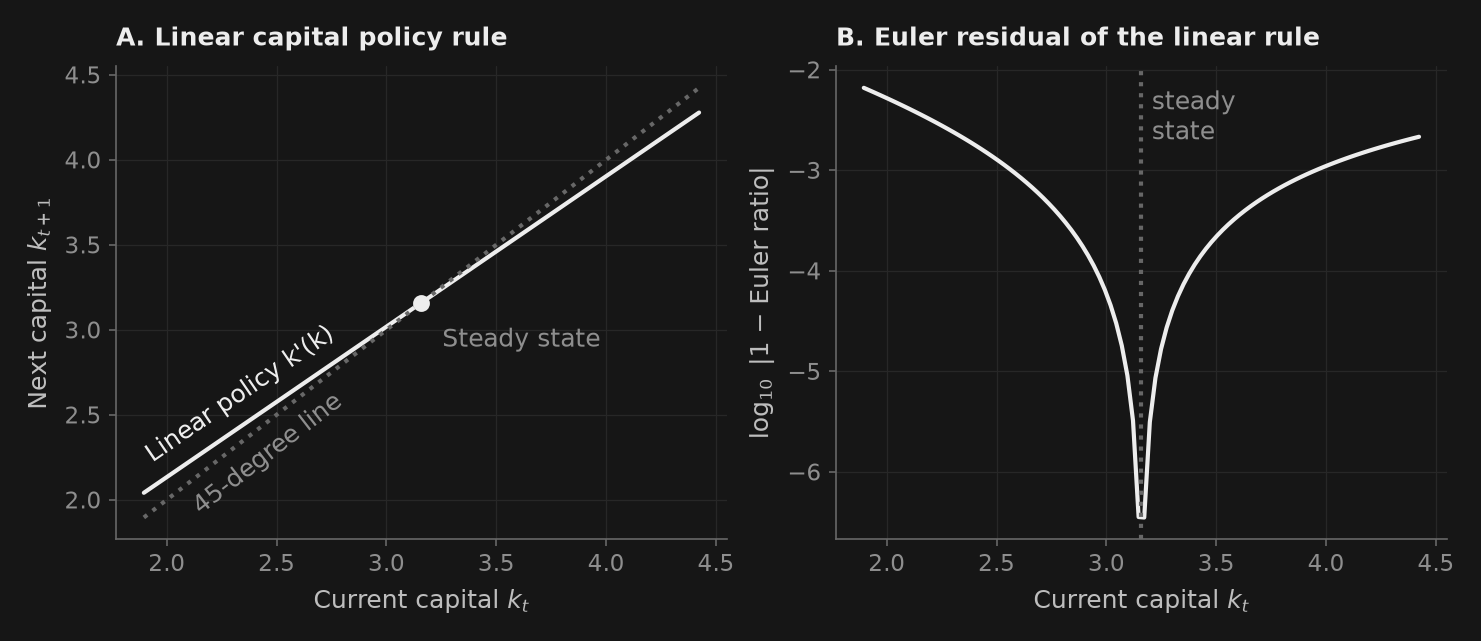

Max log10 Euler Error near Steady State (|k-k_ss| <= 5%): -4.34 (near machine precision)


In [6]:
# Grid of capital stock deviations around steady state: [0.6 * k_ss, 1.4 * k_ss]
k_ss_val = ss_base["k"]
k_grid = np.linspace(0.6 * k_ss_val, 1.4 * k_ss_val, 100)

# Local linear decision rule coefficients from Klein solution
dr = m_local.decision_rules().to_frame()
gk = dr.loc["k(-1)", "k"]
gc = dr.loc["k(-1)", "c"]
gy = dr.loc["k(-1)", "y"]

# Compute policy and Euler residuals across the grid
euler_errors = []
linear_kp = []

for k_now in k_grid:
    k_dev = k_now - k_ss_val
    # Linear policy projections
    kp_val = k_ss_val + gk * k_dev
    c_val  = ss_base["c"] + gc * k_dev

    # Next-period policy projections from kp
    kp_dev = kp_val - k_ss_val
    c_next = ss_base["c"] + gc * kp_dev
    y_next = ss_base["y"] + gy * kp_dev

    # Implied gross marginal return
    r_next = 0.33 * y_next / kp_val + 1.0 - 0.06
    # Euler equation ratio
    euler_ratio = 0.97 * (c_val / c_next) * r_next
    error_metric = np.log10(max(1e-16, abs(1.0 - euler_ratio)))
    euler_errors.append(error_metric)
    linear_kp.append(kp_val)

fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel 1: Policy Function (each name runs along its line)
ax1.plot(k_grid, linear_kp, **_nbstyle.S1)
ax1.plot(k_grid, k_grid, color=_nbstyle.SPINE, ls=":")
ax1.scatter([k_ss_val], [k_ss_val], color=_nbstyle.TINTA, s=50, zorder=5)
ax1.text(1.95, np.interp(1.95, k_grid, linear_kp) + 0.10, "Linear policy k'(k)", rotation=np.degrees(np.arctan(gk)),
         transform_rotates_text=True, rotation_mode="anchor", ha="left", va="bottom", color=_nbstyle.TINTA)
ax1.text(2.10, 2.10 - 0.10, "45-degree line", rotation=45.0, transform_rotates_text=True, rotation_mode="anchor",
         ha="left", va="top", color=_nbstyle.NOTA)
ax1.annotate("Steady state", xy=(k_ss_val, k_ss_val), xytext=(10, -12), textcoords="offset points",
             ha="left", va="top", color=_nbstyle.NOTA)
ax1.set_title("A. Linear capital policy rule")
ax1.set_xlabel("Current capital $k_t$")
ax1.set_ylabel("Next capital $k_{t+1}$")

# Panel 2: Euler Residual Curve
ax2.plot(k_grid, euler_errors, **_nbstyle.S1)
ax2.axvline(k_ss_val, color=_nbstyle.SPINE, ls=":")
ax2.annotate("steady\nstate", xy=(k_ss_val, max(euler_errors)), xytext=(5, 0), textcoords="offset points",
             ha="left", va="top", color=_nbstyle.NOTA)
ax2.set_title("B. Euler residual of the linear rule")
ax2.set_xlabel("Current capital $k_t$")
ax2.set_ylabel(r"$\log_{10}$ |1 − Euler ratio|")

plt.show()

max_err_near = np.max([e for k, e in zip(k_grid, euler_errors) if 0.95*k_ss_val <= k <= 1.05*k_ss_val])
print(f"Max log10 Euler Error near Steady State (|k-k_ss| <= 5%): {max_err_near:.2f} (near machine precision)")


## Interactive Macro Experiment: Anticipated vs. Unanticipated Technology Shocks

**The Economic Question**: In 2026, central banks and fiscal authorities actively monitor whether breakthroughs in artificial intelligence represent a current shock ($\Delta A_t$) or an anticipated future diffusion. Suppose at period $t=1$, an announcement reveals that general-purpose technology will permanently boost TFP by **$+3\%$ starting in period $t=8$**.

**Key Rational Expectations Questions**:
1. **Anticipation Effect ($1 \le t < 8$)**: Do forward-looking households wait until $t=8$ to expand consumption, or do they begin smoothing their permanent lifetime wealth increase immediately at $t=1$?
2. **Pre-Arrival Savings & Capital**: Because output has not yet increased in period $1$, how can households afford higher consumption? Does capital initially accumulate or decumulate?
3. **The Arrival Impact ($t=8$)**: When the technology actually arrives at $t=8$, does output jump smoothly or discontinuously?

Run the experiment below to simulate both the anticipated news shock and the unanticipated shock (the same $+3\%$ arriving at $t=8$ without warning: agents sit at the initial steady state until it hits, then re-plan from the capital they hold), and verify the rational expectations predictions.

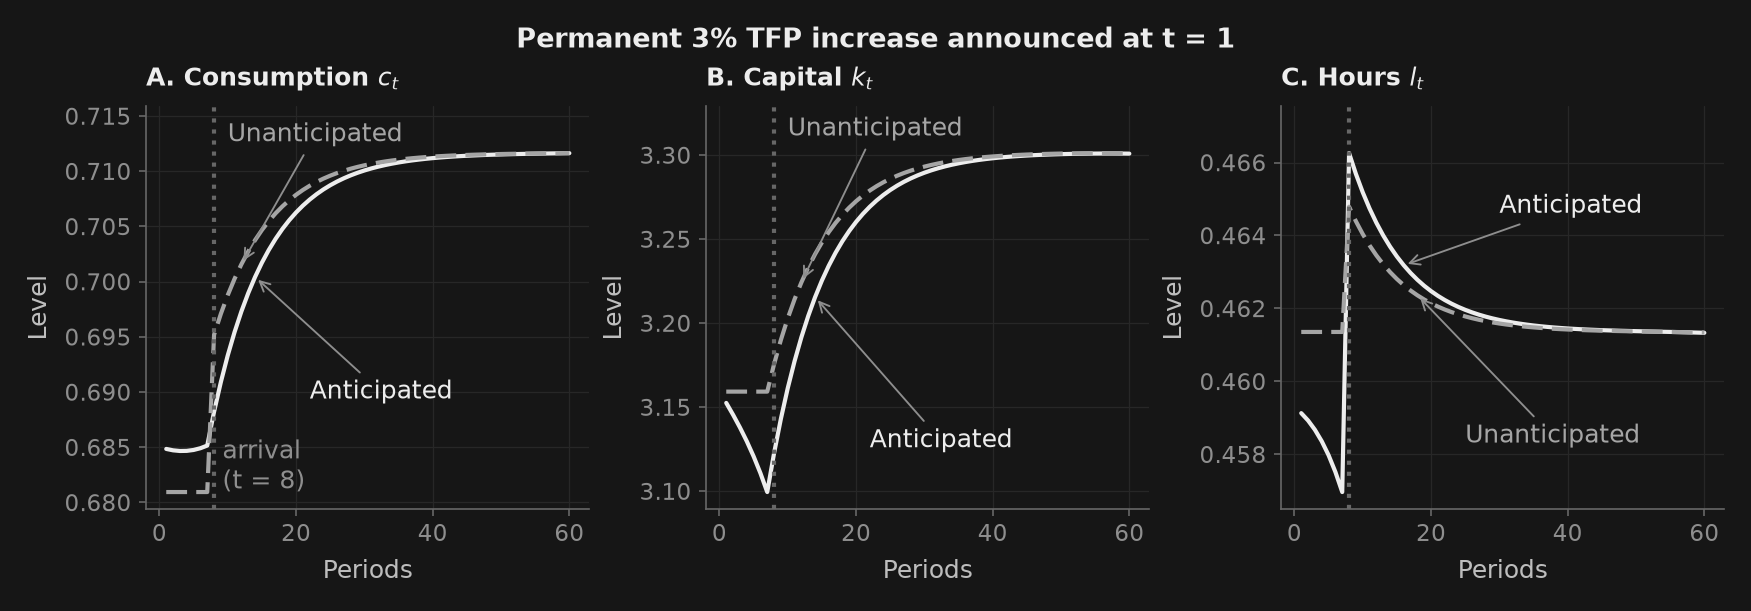

Initial Consumption Jump at t=1 upon News Announcement: 0.68485 (SS: 0.68094)
Pre-Arrival Capital Stock at t=7: 3.09948 (SS: 3.15924)
Consumption Change at Arrival (t=7 -> t=8): Anticipated +0.00306 | Unanticipated +0.01425
All rational expectations news assertions successfully passed!


In [7]:
# ==============================================================================
# Interactive News Experiment: Anticipated vs. Unanticipated Permanent TFP Shock
# ==============================================================================
T_exp = 60
a_anticipated = np.ones(T_exp)
a_anticipated[7:] = 1.03  # News announced at t=1, arrives at t=8

a_unanticipated = np.ones(T_exp)
a_unanticipated[7:] = 1.03  # Shock only known at t=8 (zero anticipation)

ss_exp_target = solve_neoclassical_ss(a_val=1.03)
y_exp_target  = np.array([ss_exp_target["y"], ss_exp_target["c"], ss_exp_target["k"], ss_exp_target["l"]])

# 1. Solve Anticipated Shock
res_anticipated = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=y_init_vector,
    y_ss=y_exp_target,
    exogenous_path=a_anticipated,
    n_periods=T_exp,
    variable_names=["y", "c", "k", "l"],
    tol=1e-10,
)

# 2. Solve Unanticipated Shock: same TFP path, but nobody learns of it until it hits at t=8.
#    Through t=7 agents expect a = 1 forever and stay at the initial steady state; at t=8 they
#    re-plan under perfect foresight from the capital they hold (k_7 = k_ss).
res_unanticipated = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=y_init_vector,
    y_ss=y_exp_target,
    exogenous_path=a_unanticipated[7:],
    n_periods=T_exp - 7,
    variable_names=["y", "c", "k", "l"],
    tol=1e-10,
)
# Realized path: initial steady state for t=1..7, then the post-news plan from t=8
path_unanticipated = pd.DataFrame(
    np.vstack([np.tile(y_init_vector, (7, 1)), res_unanticipated.path.to_numpy()]),
    index=res_anticipated.path.index,
    columns=res_anticipated.path.columns,
)

# Plotting Comparison: Anticipated News vs. Unanticipated Surprise
fig, axes = _nbstyle.figura(1, 3, sharex=True)
# Per panel: title and, for each series, the point on the curve the arrow points to and where the name goes
paneles = (
    ("c", "A. Consumption $c_t$", (14, (22, 0.690)), (12, (10, 0.7133))),
    ("k", "B. Capital $k_t$", (14, (22, 3.13)), (12, (10, 3.3155))),
    ("l", "C. Hours $l_t$", (16, (30, 0.4648)), (18, (25, 0.4585))),
)
for ax, (var, titulo, nota_ant, nota_sorp) in zip(axes, paneles):
    ant, sorp = res_anticipated.path[var], path_unanticipated[var]
    ax.plot(ant.index, ant, **_nbstyle.S1)
    ax.plot(sorp.index, sorp, **_nbstyle.S2)
    ax.axvline(8, color=_nbstyle.SPINE, ls=":")
    y0, y1 = ax.get_ylim()  # headroom above the curves, so the direct label clears them
    ax.set_ylim(y0, y1 + 0.08 * (y1 - y0))
    for serie, nombre, color, (x_curva, xytext) in ((ant, "Anticipated", _nbstyle.TINTA, nota_ant),
                                                     (sorp, "Unanticipated", _nbstyle.S2["color"], nota_sorp)):
        ax.annotate(nombre, xy=(x_curva, np.interp(x_curva, serie.index, serie)), xytext=xytext,
                    ha="left", va="center", color=color, arrowprops=_nbstyle.FLECHA)
    ax.set_title(titulo)
    ax.set_xlabel("Periods")
    ax.set_ylabel("Level")
axes[0].annotate("arrival\n(t = 8)", xy=(8, 0.03), xycoords=("data", "axes fraction"), xytext=(4, 0),
                 textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
fig.suptitle("Permanent 3% TFP increase announced at t = 1")
plt.show()

# Verification assertions
c_t1 = res_anticipated.path.loc[1, "c"]
c_ss = ss_base["c"]
k_t7 = res_anticipated.path.loc[7, "k"]
k_ss = ss_base["k"]
# Same TFP path in both economies: only the date agents learn of it differs
gap_pre_arrival = (res_anticipated.path.loc[1:7] - path_unanticipated.loc[1:7]).abs().to_numpy().max()
jump_ant = res_anticipated.path.loc[8, "c"] - res_anticipated.path.loc[7, "c"]
jump_unant = path_unanticipated.loc[8, "c"] - path_unanticipated.loc[7, "c"]

print(f"Initial Consumption Jump at t=1 upon News Announcement: {c_t1:.5f} (SS: {c_ss:.5f})")
print(f"Pre-Arrival Capital Stock at t=7: {k_t7:.5f} (SS: {k_ss:.5f})")
print(f"Consumption Change at Arrival (t=7 -> t=8): Anticipated {jump_ant:+.5f} | Unanticipated {jump_unant:+.5f}")

assert c_t1 > c_ss, "Rational expectations failure: Consumption must jump upward upon positive news."
assert k_t7 < k_ss, "Economic mechanism failure: Capital must decumulate before technology arrives to finance consumption."
assert res_unanticipated.converged, "The post-news perfect-foresight solve did not converge."
assert gap_pre_arrival > 1e-3, "Anticipated and unanticipated paths must differ before the technology arrives."
assert jump_unant > jump_ant, "A surprise must move consumption at arrival by more than an anticipated shock does."
print("All rational expectations news assertions successfully passed!")

## The Phase Diagram, Computed Rather Than Drawn

Every textbook draws the Ramsey phase diagram in $(k, c)$ space by hand: two nullclines crossing at the steady state, a stable arm sloping upward, and arrows pointing away everywhere else. Here we **compute** it from the same structural equations that `load_mod` parses, so nothing is stylized.

The complication relative to the textbook is that labor is endogenous. But hours are pinned down statically: given a capital stock $k$ and a consumption level $c$, the intratemporal condition
$$ \gamma c\,l^{\alpha} = (1-\alpha)\,a\,k^{\alpha}(\bar n - l) $$
has a unique root $l(k, c)$, monotone in both arguments (more consumption buys more leisure). With that map in hand the two loci are ordinary one-dimensional root problems:

- **$\Delta k = 0$** (capital stationary): $c = a k^{\alpha} l(k,c)^{1-\alpha} - \delta k$ — the familiar hump, peaking at the golden-rule capital stock.
- **$\Delta c = 0$** (consumption stationary): $\alpha\, a\, k^{\alpha-1} l(k,c)^{1-\alpha} = \beta^{-1} - 1 + \delta$ — the modified golden rule, downward sloping here because higher $c$ lowers hours and therefore lowers the marginal product of capital.

The **saddle path** is then traced by brute force: solve the non-linear perfect-foresight problem from several initial capital stocks and plot the realized $(k_{t-1}, c_t)$ pairs. Overlaying the *linear* stable arm $c = c_{ss} + g_c (k - k_{ss})$ from the Klein solution shows exactly where — and in which direction — the first-order approximation departs from the truth.

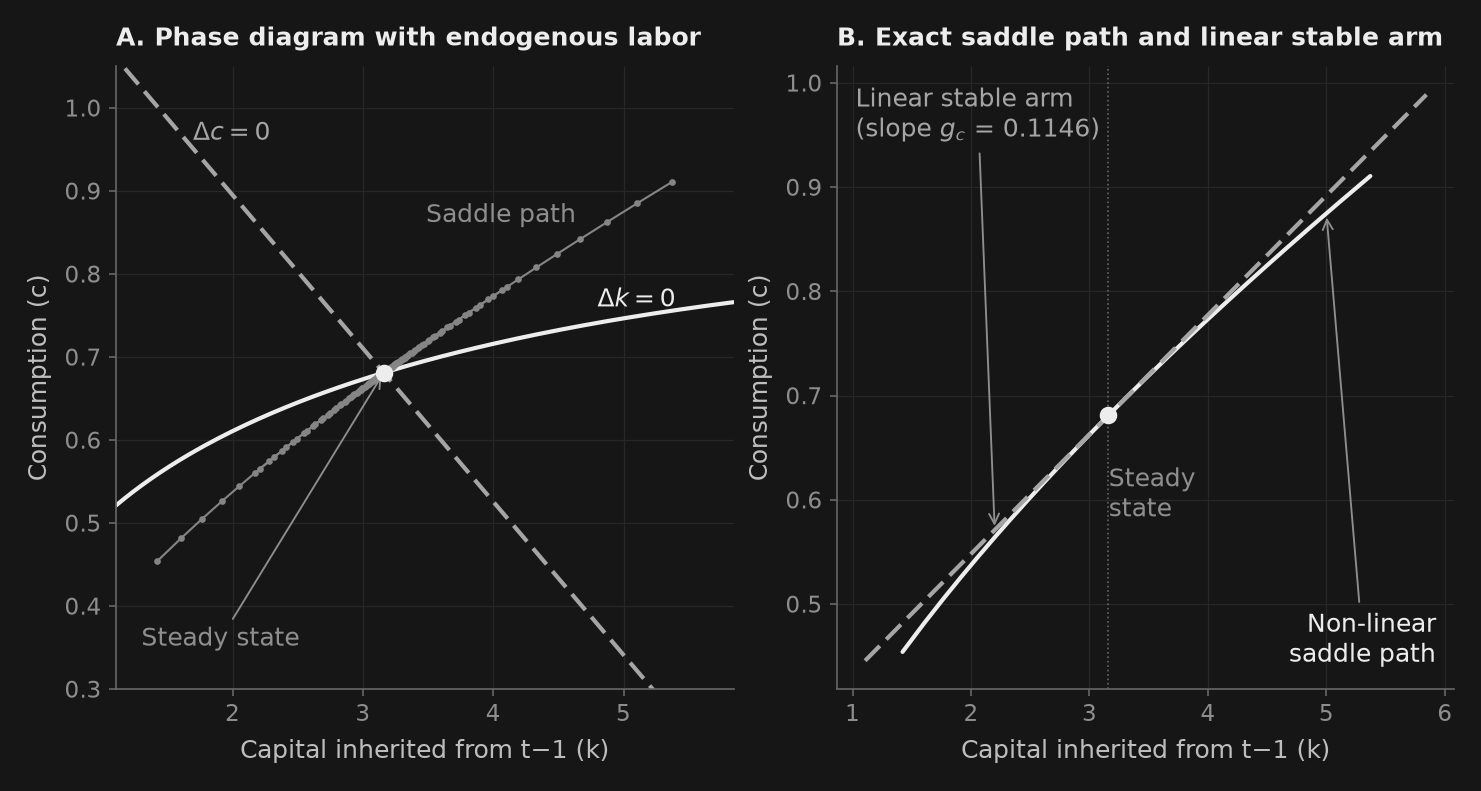

Golden-rule capital (peak of the Delta-k = 0 locus): 5.8446
Modified golden-rule capital (steady state)        : 3.1592  -> dynamically efficient
At k = 0.45 k_ss: true c = 0.45401 vs. linear arm 0.48180  (+6.12%)
At k = 1.70 k_ss: true c = 0.91061 vs. linear arm 0.93439  (+2.61%)
Phase-diagram assertions passed: nullclines cross at the steady state and the stable arm is a chord of a concave policy.


In [8]:
# ==============================================================================
# Phase Diagram: Nullclines, the Non-Linear Saddle Path, and the Linear Stable Arm
# ==============================================================================
from scipy.optimize import brentq

ALPHA_P, BETA_P, DELTA_P, GAMMA_P, NBAR_P = 0.33, 0.97, 0.06, 1.0, 1.0
_BRENT = dict(xtol=1e-14, rtol=1e-15)


def hours_at(k, c, a_val=1.0):
    """Hours solving the intratemporal condition at a given (k, c) pair."""
    scale = (1.0 - ALPHA_P) * a_val * k ** ALPHA_P
    resid = lambda l: GAMMA_P * c * l ** ALPHA_P + scale * l - scale * NBAR_P
    return brentq(resid, 1e-12, NBAR_P - 1e-12, **_BRENT)


def locus_delta_k(k, a_val=1.0):
    """Consumption on the Delta-k = 0 nullcline: c = y(k, l(k,c)) - delta*k."""
    resid = lambda c: a_val * k ** ALPHA_P * hours_at(k, c, a_val) ** (1.0 - ALPHA_P) - DELTA_P * k - c
    return brentq(resid, 1e-10, a_val * k ** ALPHA_P * NBAR_P ** (1.0 - ALPHA_P), **_BRENT)


def locus_delta_c(k, a_val=1.0):
    """Consumption on the Delta-c = 0 nullcline: alpha * y / k = 1/beta - 1 + delta.

    Returns NaN where the locus does not exist: below a threshold capital stock the
    marginal product exceeds the required return however little the household works.
    """
    r_target = 1.0 / BETA_P - 1.0 + DELTA_P
    resid = lambda c: ALPHA_P * a_val * k ** (ALPHA_P - 1.0) * hours_at(k, c, a_val) ** (1.0 - ALPHA_P) - r_target
    c_max = a_val * k ** ALPHA_P * NBAR_P ** (1.0 - ALPHA_P)
    if resid(1e-10) * resid(c_max) > 0.0:
        return np.nan
    return brentq(resid, 1e-10, c_max, **_BRENT)


k_ss_ref, c_ss_ref = ss_base["k"], ss_base["c"]

# Both nullclines must pass exactly through the analytical steady state
assert abs(locus_delta_k(k_ss_ref) - c_ss_ref) < 1e-10, "Delta-k nullcline misses the steady state."
assert abs(locus_delta_c(k_ss_ref) - c_ss_ref) < 1e-10, "Delta-c nullcline misses the steady state."

k_phase = np.linspace(0.35 * k_ss_ref, 1.85 * k_ss_ref, 140)
c_kdot = np.array([locus_delta_k(k) for k in k_phase])
c_cdot = np.array([locus_delta_c(k) for k in k_phase])

# Trace the true saddle path: perfect-foresight transitions from four initial capital stocks
T_saddle = 140
y_ss_saddle = np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]])
saddle_paths = {}
for frac in (0.45, 0.70, 1.30, 1.70):
    k0 = frac * k_ss_ref
    res_sp = solve_perfect_foresight(
        neoclassical_stacked_equations,
        y_init=np.array([ss_base["y"], ss_base["c"], k0, ss_base["l"]]),
        y_ss=y_ss_saddle,
        exogenous_path=np.ones(T_saddle),
        n_periods=T_saddle,
        variable_names=["y", "c", "k", "l"],
        tol=1e-11,
        max_iter=80,
    )
    assert res_sp.converged, f"Saddle-path solve failed for k0 = {frac} * k_ss."
    # Pair each period's consumption with the capital stock inherited from t-1
    k_lagged = np.concatenate([[k0], res_sp.path["k"].values[:-1]])
    saddle_paths[frac] = (k_lagged, res_sp.path["c"].values)

# Linear stable arm implied by the Klein decision rule
gc_arm = m_local.decision_rules().to_frame().loc["k(-1)", "c"]
c_linear_arm = c_ss_ref + gc_arm * (k_phase - k_ss_ref)

# Under the "lamina" profile the figure inherits the slide slot's size;
# in the notebook it takes the course grid.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, (ax_ph, ax_arm) = _nbstyle.figura(1, 2, alto=True, figsize=_ranura)

# Panel 1: the phase diagram
ax_ph.plot(k_phase, c_kdot, **_nbstyle.S1)
ax_ph.plot(k_phase, c_cdot, **_nbstyle.S2)
for k_tr, c_tr in saddle_paths.values():
    ax_ph.plot(k_tr, c_tr, color=_nbstyle.S5["color"], lw=1.0, ls="-", marker="o", markersize=2.2)
ax_ph.scatter([k_ss_ref], [c_ss_ref], color=_nbstyle.TINTA, s=55, zorder=6)
ax_ph.annotate(r"$\Delta k = 0$", xy=(4.8, np.interp(4.8, k_phase, c_kdot)), xytext=(0, 5), textcoords="offset points",
               ha="left", va="bottom", color=_nbstyle.TINTA)
ax_ph.annotate(r"$\Delta c = 0$", xy=(1.6, np.interp(1.6, k_phase, c_cdot)), xytext=(6, 0), textcoords="offset points",
               ha="left", va="center", color=_nbstyle.S2["color"])
k_silla, c_silla = saddle_paths[1.70]
ax_ph.annotate("Saddle path", xy=(4.7, np.interp(4.7, k_silla[::-1], c_silla[::-1])), xytext=(-4, 4),
               textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)
ax_ph.annotate("Steady state", xy=(k_ss_ref, c_ss_ref), xytext=(1.3, 0.36),
               ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_ph.set_xlim(k_phase[0], k_phase[-1])
ax_ph.set_ylim(0.30, 1.05)
ax_ph.set_title("A. Phase diagram with endogenous labor")
ax_ph.set_xlabel("Capital inherited from t−1 (k)")
ax_ph.set_ylabel("Consumption (c)")

# Panel 2: true saddle path vs. the first-order stable arm
k_true = np.concatenate([saddle_paths[f][0] for f in (0.45, 0.70, 1.30, 1.70)])
c_true = np.concatenate([saddle_paths[f][1] for f in (0.45, 0.70, 1.30, 1.70)])
order = np.argsort(k_true)
ax_arm.plot(k_true[order], c_true[order], **_nbstyle.S1)
ax_arm.plot(k_phase, c_linear_arm, **_nbstyle.S2)
ax_arm.scatter([k_ss_ref], [c_ss_ref], color=_nbstyle.TINTA, s=55, zorder=6)
ax_arm.axvline(k_ss_ref, color=_nbstyle.SPINE, ls=":", lw=0.8)
# The two curves leave two empty triangles, upper left and lower right; each
# label is anchored in one of them in axes fractions, so it keeps landing in
# the gap at any width.
ax_arm.annotate(f"Linear stable arm\n(slope $g_c$ = {gc_arm:.4f})",
                xy=(2.2, c_ss_ref + gc_arm * (2.2 - k_ss_ref)), xytext=(0.03, 0.97),
                textcoords="axes fraction", ha="left", va="top",
                color=_nbstyle.S2["color"], arrowprops=_nbstyle.FLECHA)
ax_arm.annotate("Non-linear\nsaddle path", xy=(5.0, np.interp(5.0, k_true[order], c_true[order])),
                xytext=(0.97, 0.03), textcoords="axes fraction", ha="right", va="bottom",
                color=_nbstyle.TINTA, arrowprops=_nbstyle.FLECHA)
# In axes fraction as well: with a fixed offset in points the label takes up
# more relative width in the slot than in the notebook, and its last letter
# ended up touching the arrow that rises from the bottom-right corner.
ax_arm.annotate("Steady\nstate", xy=(k_ss_ref, c_ss_ref), xytext=(0.44, 0.36),
                textcoords="axes fraction", ha="left", va="top", color=_nbstyle.NOTA)
ax_arm.set_title("B. Exact saddle path and linear stable arm")
ax_arm.set_xlabel("Capital inherited from t−1 (k)")
ax_arm.set_ylabel("Consumption (c)")

plt.show()

# Quantify the gap between the linear arm and the true policy at the extremes
k_lo, k_hi = 0.45 * k_ss_ref, 1.70 * k_ss_ref
c_true_lo, c_true_hi = saddle_paths[0.45][1][0], saddle_paths[1.70][1][0]
c_lin_lo = c_ss_ref + gc_arm * (k_lo - k_ss_ref)
c_lin_hi = c_ss_ref + gc_arm * (k_hi - k_ss_ref)
print(f"Golden-rule capital (peak of the Delta-k = 0 locus): {k_phase[int(np.argmax(c_kdot))]:.4f}")
print(f"Modified golden-rule capital (steady state)        : {k_ss_ref:.4f}  -> dynamically efficient")
print(f"At k = 0.45 k_ss: true c = {c_true_lo:.5f} vs. linear arm {c_lin_lo:.5f}  ({(c_lin_lo/c_true_lo - 1)*100:+.2f}%)")
print(f"At k = 1.70 k_ss: true c = {c_true_hi:.5f} vs. linear arm {c_lin_hi:.5f}  ({(c_lin_hi/c_true_hi - 1)*100:+.2f}%)")

# The steady state sits strictly to the left of the golden rule: no dynamic inefficiency
assert k_ss_ref < k_phase[int(np.argmax(c_kdot))], "Steady state must lie below the golden-rule capital stock."
# Concavity of the true policy puts the linear arm above it on both sides of k_ss
assert c_lin_lo > c_true_lo and c_lin_hi > c_true_hi, "Linear arm must overstate consumption away from k_ss."
print("Phase-diagram assertions passed: nullclines cross at the steady state and the stable arm is a chord of a concave policy.")

## How Fast Does Capital Converge? The Stable Eigenvalue Meets the "Iron Law" of 2%

The stable eigenvalue of the Klein decomposition is not a numerical curiosity: it *is* the model's prediction about how quickly poor economies catch up. The linear transition obeys
$$ k_t - k_{ss} = g_k\,(k_{t-1} - k_{ss}), \qquad \lambda \equiv 1 - g_k, \qquad t_{1/2} = \frac{\ln 0.5}{\ln g_k}, $$
where $\lambda$ is the annual rate of convergence (the calibration here is annual) and $t_{1/2}$ the half-life of an initial capital gap.

The empirical benchmark is one of the most replicated findings in growth economics: conditional convergence at roughly **2% per year** (Barro 1991, Barro & Sala-i-Martin 1992, Mankiw, Romer & Weil 1992) — a half-life near 35 years. The textbook neoclassical model with $\alpha = 1/3$ predicts something far faster. The question this experiment answers is: *how far does the capital share have to be pushed before the model reproduces the empirical speed?*

The answer is the Mankiw–Romer–Weil argument in one number. Interpreting $\alpha$ as the share of **broad** capital — physical plus human — rather than plant and equipment alone is exactly the move that reconciles the model's convergence speed with the data. We also verify that the linear half-life is a faithful summary of the true non-linear transition, by timing an economy that starts with half the steady-state capital stock.

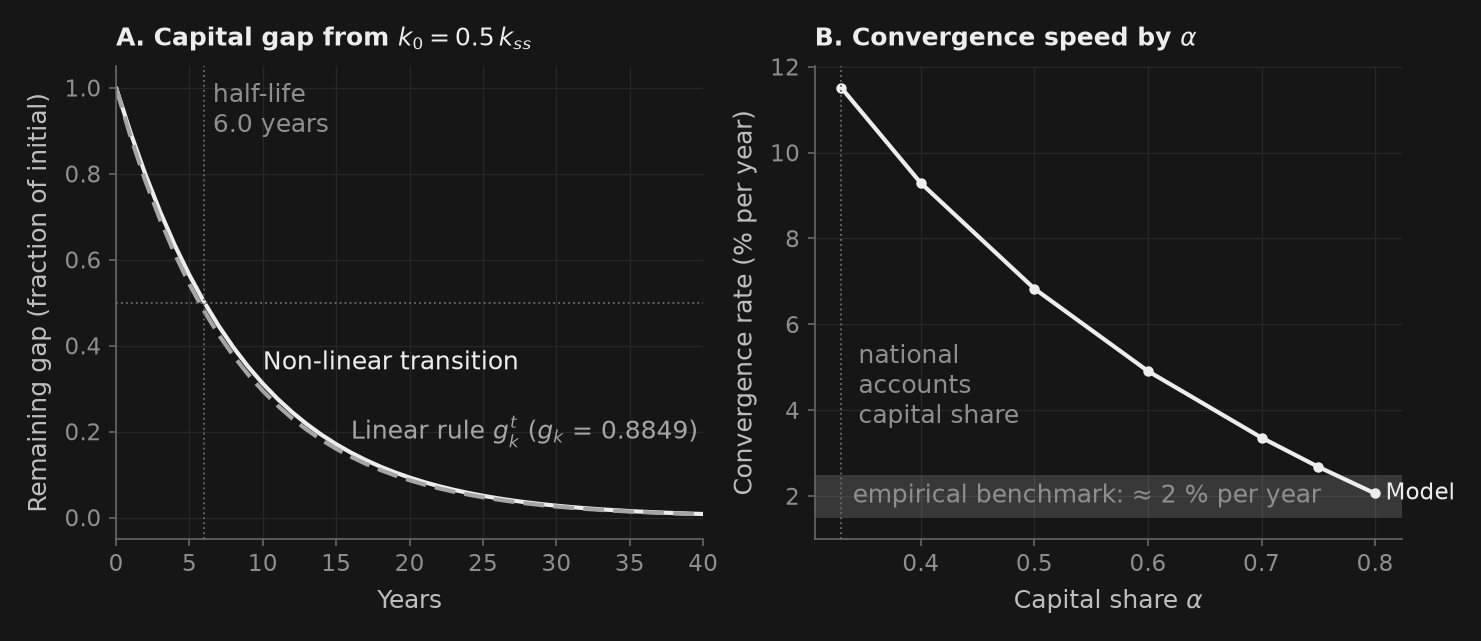

CONVERGENCE SPEED ACROSS CAPITAL SHARES:
 alpha (capital share)  Stable root g_k  Convergence lambda (%/yr)  Half-life (years)  Capital-output ratio k/y
                  0.33          0.88493                      11.51                5.7                      3.63
                  0.40          0.90713                       9.29                7.1                      4.40
                  0.50          0.93171                       6.83                9.8                      5.50
                  0.60          0.95086                       4.91               13.8                      6.60
                  0.70          0.96640                       3.36               20.3                      7.70
                  0.75          0.97316                       2.68               25.5                      8.25
                  0.80          0.97938                       2.06               33.3                      8.80

Baseline alpha = 0.33: linear half-life 5.67 years, non-linear

In [9]:
# ==============================================================================
# Convergence Speed: Linear Eigenvalue, Non-Linear Half-Life, and the Capital Share
# ==============================================================================
def linear_convergence(alpha_val):
    """Convergence rate and half-life implied by the Klein stable root at a given alpha."""
    ss_a = solve_neoclassical_ss(alpha=alpha_val)
    m_a = load_mod(mod_path, params={"alpha": alpha_val},
                   steady_state={"y": ss_a["y"], "c": ss_a["c"], "k": ss_a["k"], "l": ss_a["l"], "a": 0.0})
    gk_a = m_a.decision_rules().to_frame().loc["k(-1)", "k"]
    return gk_a, 1.0 - gk_a, np.log(0.5) / np.log(gk_a), ss_a["k"] / ss_a["y"]


alpha_grid = [0.33, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80]
conv_rows = []
for a_val in alpha_grid:
    gk_a, lam_a, hl_a, ky_a = linear_convergence(a_val)
    conv_rows.append({
        "alpha (capital share)": a_val,
        "Stable root g_k": round(gk_a, 5),
        "Convergence lambda (%/yr)": round(lam_a * 100, 2),
        "Half-life (years)": round(hl_a, 1),
        "Capital-output ratio k/y": round(ky_a, 2),
    })
conv_df = pd.DataFrame(conv_rows)

# Non-linear check: start at half the steady-state capital stock and time the true transition
T_conv = 200
res_conv = solve_perfect_foresight(
    neoclassical_stacked_equations,
    y_init=np.array([ss_base["y"], ss_base["c"], 0.5 * k_ss_ref, ss_base["l"]]),
    y_ss=np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]]),
    exogenous_path=np.ones(T_conv),
    n_periods=T_conv,
    variable_names=["y", "c", "k", "l"],
    tol=1e-11,
    max_iter=80,
)
assert res_conv.converged, "Convergence experiment failed to solve."

k_path_conv = np.concatenate([[0.5 * k_ss_ref], res_conv.path["k"].values])
gap_nl = (k_path_conv - k_ss_ref) / (0.5 * k_ss_ref - k_ss_ref)   # normalised gap, starts at 1
gk_base, lam_base, hl_base, _ = linear_convergence(0.33)
gap_lin = gk_base ** np.arange(len(gap_nl))

cross = int(np.argmax(gap_nl < 0.5))
hl_nonlinear = cross - 1 + (gap_nl[cross - 1] - 0.5) / (gap_nl[cross - 1] - gap_nl[cross])

fig, (ax_gap, ax_lam) = _nbstyle.figura(1, 2)

# Panel 1: normalised capital gap, non-linear vs. linear (the two curves overlap)
anios = np.arange(len(gap_nl))
ax_gap.plot(anios, gap_nl, **_nbstyle.S1)
ax_gap.plot(anios, gap_lin, **_nbstyle.S2)
ax_gap.annotate("Non-linear transition", xy=(10, np.interp(10, anios, gap_nl)), xytext=(0, 4),
                textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TINTA)
ax_gap.annotate(f"Linear rule $g_k^t$ ($g_k$ = {gk_base:.4f})", xy=(16, np.interp(16, anios, gap_lin)), xytext=(0, 4),
                textcoords="offset points", ha="left", va="bottom", color=_nbstyle.S2["color"])
ax_gap.axhline(0.5, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_gap.axvline(hl_nonlinear, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_gap.annotate(f"half-life\n{hl_nonlinear:.1f} years", xy=(hl_nonlinear, 0.97), xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA)
ax_gap.set_xlim(0, 40)
ax_gap.set_title(r"A. Capital gap from $k_0 = 0.5\,k_{ss}$")
ax_gap.set_xlabel("Years")
ax_gap.set_ylabel("Remaining gap (fraction of initial)")

# Panel 2: convergence rate against the empirical 2% benchmark
ax_lam.plot(conv_df["alpha (capital share)"], conv_df["Convergence lambda (%/yr)"],
            **_nbstyle.S1, marker="o", markersize=4, label="Model")
ax_lam.axhspan(1.5, 2.5, color=_nbstyle.BANDA, lw=0)
ax_lam.annotate("empirical benchmark: ≈ 2 % per year", xy=(0.34, 2.0), ha="left", va="center", color=_nbstyle.NOTA)
ax_lam.axvline(0.33, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_lam.annotate("national\naccounts\ncapital share", xy=(0.345, 5.6),
                ha="left", va="top", color=_nbstyle.NOTA)
ax_lam.set_title(r"B. Convergence speed by $\alpha$")
ax_lam.set_xlabel(r"Capital share $\alpha$")
ax_lam.set_ylabel("Convergence rate (% per year)")
_nbstyle.etiquetar(ax_lam)

plt.show()

print("CONVERGENCE SPEED ACROSS CAPITAL SHARES:")
print(conv_df.to_string(index=False))
print(f"\nBaseline alpha = 0.33: linear half-life {hl_base:.2f} years, non-linear half-life {hl_nonlinear:.2f} years.")
print(f"The linear rule is accurate about the *speed* even when the level gap is 50%: difference of {abs(hl_base - hl_nonlinear):.2f} years.")

idx_match = int(np.argmin(np.abs(conv_df["Convergence lambda (%/yr)"].values - 2.0)))
alpha_match = float(conv_df.loc[idx_match, "alpha (capital share)"])
lam_match = float(conv_df.loc[idx_match, "Convergence lambda (%/yr)"])
print(f"Closest match to the empirical 2%/yr: alpha = {alpha_match:.2f} delivers {lam_match:.2f}%/yr "
      f"and a capital-output ratio of {conv_df.loc[idx_match, 'Capital-output ratio k/y']:.1f} "
      "(Mankiw-Romer-Weil broad capital: physical plus human).")

assert lam_base * 100 > 5.0, "With alpha = 0.33 the model must converge far faster than the data."
assert alpha_match > 0.6, "Reproducing 2%/yr convergence must require a broad-capital share well above 1/3."
assert abs(hl_base - hl_nonlinear) < 1.0, "Linear and non-linear half-lives must agree to well under a year."
print(f"Convergence assertions passed: at alpha = 0.33 the model overpredicts catch-up speed by a factor of "
      f"{lam_base * 100 / 2.0:.1f}.")

## How Large Can a Shock Be Before the Linear Rule Breaks?

Section 5 measured accuracy on a grid of capital stocks. The complementary question is about the **size of the disturbance**: a first-order perturbation is exact to $O(\varepsilon)$, so its error along a transition path should scale as $O(\varepsilon^2)$. That is a sharp, falsifiable prediction, and it is the practical rule of thumb behind "linearize for business cycles, solve globally for crises".

The experiment: for permanent productivity shifts of $+0.5\%, +1\%, \dots, +20\%$, compute
1. the **exact** transition with the stacked Newton solver, and
2. the **first-order** transition $k_t - k'_{ss} = g_k (k_{t-1} - k'_{ss})$, $c_t = c'_{ss} + g_c (k_{t-1} - k'_{ss})$, anchored at the new steady state,

and record the largest percentage discrepancy along the path. Regressing $\log(\text{error})$ on $\log(\text{shock size})$ should return a slope of 2. If it does, the theory of perturbation is confirmed numerically rather than asserted — and the practical consequence is immediate: quadrupling the shock multiplies the approximation error by sixteen.

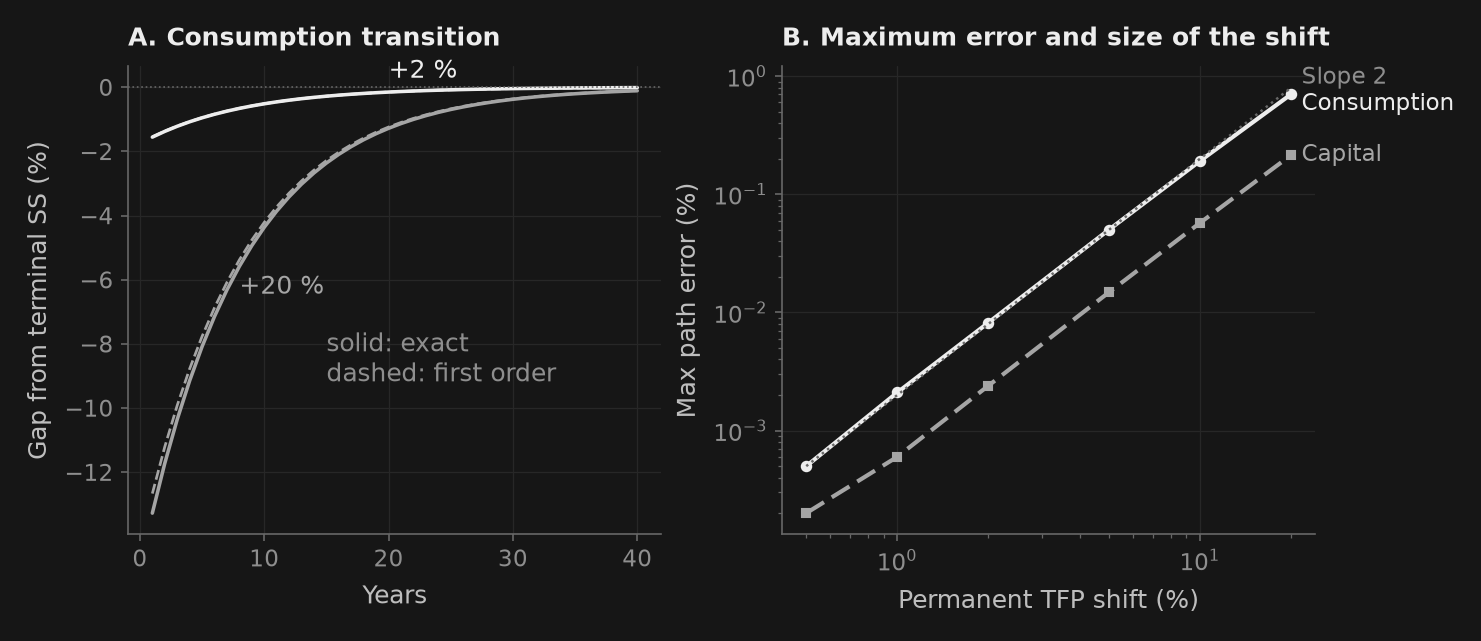

FIRST-ORDER ACCURACY AS A FUNCTION OF SHOCK SIZE:
Permanent TFP shift  Max error in c (%)  Max error in k (%)
              +0.5%              0.0005              0.0002
              +1.0%              0.0021              0.0006
              +2.0%              0.0082              0.0024
              +5.0%              0.0501              0.0148
             +10.0%              0.1916              0.0573
             +20.0%              0.7034              0.2150

Fitted log-log slope for consumption error: 1.964  (perturbation theory predicts 2)
Fitted log-log slope for capital error    : 1.920
A business-cycle-sized 2% shift costs 0.008% accuracy; a 20% shift costs 0.703%.
Accuracy assertions passed: linearize for the cycle, solve globally for the crisis.


In [10]:
# ==============================================================================
# Approximation Error vs. Shock Size: the Quadratic Law of First-Order Perturbation
# ==============================================================================
gk_lin, gc_lin = [m_local.decision_rules().to_frame().loc["k(-1)", v] for v in ("k", "c")]
T_acc = 100
shock_sizes = np.array([0.005, 0.01, 0.02, 0.05, 0.10, 0.20])
acc_rows = []
paths_store = {}

for shock in shock_sizes:
    ss_target = solve_neoclassical_ss(a_val=1.0 + shock)
    res_acc = solve_perfect_foresight(
        neoclassical_stacked_equations,
        y_init=np.array([ss_base["y"], ss_base["c"], ss_base["k"], ss_base["l"]]),
        y_ss=np.array([ss_target["y"], ss_target["c"], ss_target["k"], ss_target["l"]]),
        exogenous_path=np.full(T_acc, 1.0 + shock),
        n_periods=T_acc,
        variable_names=["y", "c", "k", "l"],
        tol=1e-11,
        max_iter=80,
    )
    assert res_acc.converged, f"Non-linear solve failed for a +{shock:.1%} permanent shift."

    # First-order transition anchored at the NEW steady state
    k_lin_path = np.empty(T_acc)
    c_lin_path = np.empty(T_acc)
    k_prev = ss_base["k"]
    for t in range(T_acc):
        dev = k_prev - ss_target["k"]
        c_lin_path[t] = ss_target["c"] + gc_lin * dev
        k_lin_path[t] = ss_target["k"] + gk_lin * dev
        k_prev = k_lin_path[t]

    c_nl_path = res_acc.path["c"].values
    k_nl_path = res_acc.path["k"].values
    err_c = float(np.max(np.abs(c_lin_path - c_nl_path) / c_nl_path) * 100)
    err_k = float(np.max(np.abs(k_lin_path - k_nl_path) / k_nl_path) * 100)
    acc_rows.append({"Permanent TFP shift": f"+{shock*100:.1f}%",
                     "Max error in c (%)": round(err_c, 4),
                     "Max error in k (%)": round(err_k, 4)})
    paths_store[shock] = (c_nl_path, c_lin_path, ss_target["c"])

acc_df = pd.DataFrame(acc_rows)
err_c_arr = np.array([r["Max error in c (%)"] for r in acc_rows])
err_k_arr = np.array([r["Max error in k (%)"] for r in acc_rows])

fig, (ax_paths, ax_scale) = _nbstyle.figura(1, 2)

# Panel 1: consumption transitions for a small and a large permanent shift.
# Exact and first order overlap, so each pair carries a single name: the size of the shift.
horizon = np.arange(1, 41)
for shock, estilo, (x_nombre, ha, va, dy) in ((0.02, _nbstyle.S1, (20, "left", "bottom", 4)),
                                              (0.20, _nbstyle.S2, (8, "left", "top", -4))):
    c_nl, c_lin, c_term = paths_store[shock]
    brecha_nl = (c_nl[:40] / c_term - 1.0) * 100
    ax_paths.plot(horizon, brecha_nl, color=estilo["color"], lw=1.7, ls="-")
    ax_paths.plot(horizon, (c_lin[:40] / c_term - 1.0) * 100, color=estilo["color"], lw=1.3, ls="--")
    ax_paths.annotate(f"+{shock*100:.0f} %", xy=(x_nombre, np.interp(x_nombre, horizon, brecha_nl)), xytext=(0, dy),
                      textcoords="offset points", ha=ha, va=va, color=estilo["color"])
ax_paths.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_paths.annotate("solid: exact\ndashed: first order", xy=(15, -8.5),
                  ha="left", va="center", color=_nbstyle.NOTA)
ax_paths.set_title("A. Consumption transition")
ax_paths.set_xlabel("Years")
ax_paths.set_ylabel("Gap from terminal SS (%)")

# Panel 2: the quadratic scaling law
ax_scale.loglog(shock_sizes * 100, err_c_arr, **_nbstyle.S1, marker="o", markersize=4.5, label="Consumption")
ax_scale.loglog(shock_sizes * 100, err_k_arr, **_nbstyle.S2, marker="s", markersize=4, label="Capital")
ref = err_c_arr[0] * (shock_sizes / shock_sizes[0]) ** 2
ax_scale.loglog(shock_sizes * 100, ref, color=_nbstyle.SPINE, ls=":", lw=1.2, label="Slope 2")
ax_scale.set_title("B. Maximum error and size of the shift")
ax_scale.set_xlabel("Permanent TFP shift (%)")
ax_scale.set_ylabel("Max path error (%)")
_nbstyle.etiquetar(ax_scale, donde="fin")

plt.show()

slope_c = float(np.polyfit(np.log(shock_sizes), np.log(err_c_arr), 1)[0])
slope_k = float(np.polyfit(np.log(shock_sizes), np.log(err_k_arr), 1)[0])

print("FIRST-ORDER ACCURACY AS A FUNCTION OF SHOCK SIZE:")
print(acc_df.to_string(index=False))
print(f"\nFitted log-log slope for consumption error: {slope_c:.3f}  (perturbation theory predicts 2)")
print(f"Fitted log-log slope for capital error    : {slope_k:.3f}")
print(f"A business-cycle-sized 2% shift costs {err_c_arr[2]:.3f}% accuracy; a 20% shift costs {err_c_arr[-1]:.3f}%.")

assert 1.8 < slope_c < 2.2, f"Consumption error must scale quadratically, got slope {slope_c:.3f}."
assert 1.8 < slope_k < 2.2, f"Capital error must scale quadratically, got slope {slope_k:.3f}."
assert err_c_arr[2] < 0.05, "A 2% shift must stay well inside a tenth of a percent of accuracy."
print("Accuracy assertions passed: linearize for the cycle, solve globally for the crisis.")